# Ideology and Emotional Tone
Party Above All: The Determinants of Emotional Tone in French Campaign Manifestos
### Author: Salma El-Aazdoudi

---

## Research Question

> **Do candidates further from the political centre use a different emotional register in their *professions de foi*?**

### Hypothesis
Candidates at the ideological extremes (far-left, far-right) use **more emotionally intense** language than mainstream candidates. This would produce a **U-shaped** pattern: emotional intensity increases as we move away from the centre in either direction.

## 0. Setup

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = {
    "far_left":  "#7c3aed",
    "left":      "#185FA5",
    "ecologist": "#16a34a",
    "right":     "#A32D2D",
    "far_right": "#7f1d1d",
}
POSITION_ORDER  = ["far_left", "left", "ecologist", "right", "far_right"]
POSITION_LABELS = ["Far left", "Left", "Ecologist", "Right", "Far right"]

print("All libraries loaded.")


All libraries loaded.


In [11]:
# ── Load df_full ─────────────────────────────────────────────────────────
df = pd.read_csv("/Users/salmaelaazdoudi/Desktop/nlp/df_final_emotions.csv")

In [12]:
df.columns

Index(['filename', 'year', 'text', 'n_words', 'id', 'date', 'subject', 'title',
       'contexte-election', 'contexte-tour', 'cote', 'departement',
       'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations',
       'nuance_matc

## 1. Emotional Tone by Political Bloc: Descriptive Patterns

### 1.1. Emotional Intensity

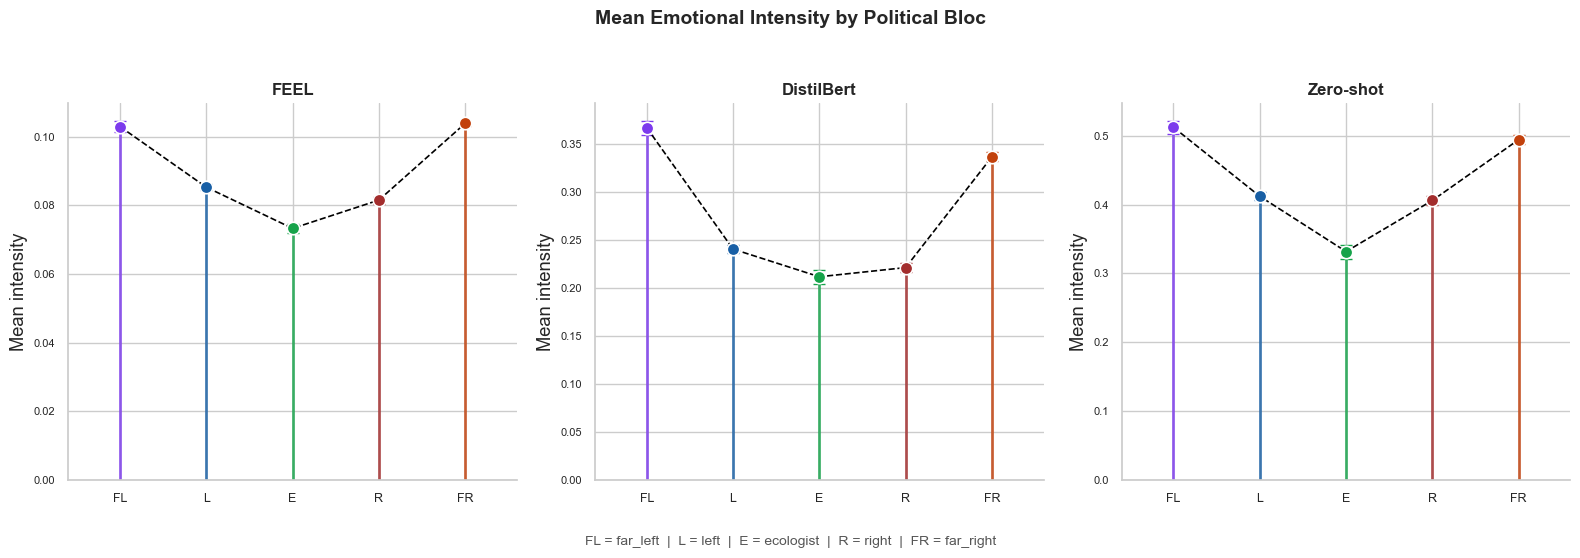

Figure saved.


In [16]:
INTENSITY_COLS = {
    "FEEL":       "feel_intensity_nrc",
    "DistilBert": "tr_intensity_nrc",
    "Zero-shot":      "zs_intensity_nrc",
}

BLOC_ORDER  = ["far_left", "left", "ecologist", "right", "far_right"]
BLOC_COLORS = ["#7c3aed", "#185FA5", "#16a34a", "#A32D2D", "#c2410c"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("Mean Emotional Intensity by Political Bloc",
             fontsize=14, fontweight="bold", y=1.03)

for ax, (label, col) in zip(axes, INTENSITY_COLS.items()):
    if col not in df.columns:
        ax.set_visible(False)
        continue

    stats = (
        df.groupby("bloc")[col]
        .agg(["mean", "std", "count"])
        .reindex(BLOC_ORDER)
    )
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])

    x = range(len(BLOC_ORDER))

    for i, (mean_val, ci_val, color) in enumerate(
        zip(stats["mean"], stats["ci95"], BLOC_COLORS)
    ):
        ax.vlines(i, 0, mean_val, color=color, linewidth=2, alpha=0.8)
        ax.plot(i, mean_val, "o", color=color, markersize=9,
                markeredgecolor="white", markeredgewidth=1.2, zorder=3)
        ax.errorbar(i, mean_val, yerr=ci_val, fmt="none",
                    color=color, capsize=4, linewidth=1.2)

    ax.plot(list(x), stats["mean"].values,
            color="black", linewidth=1.2, linestyle="--", zorder=2)

    ax.set_title(label, fontweight="bold", fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(["FL", "L", "E", "R", "FR"], fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(-0.6, len(BLOC_ORDER) - 0.4)
    ax.set_ylim(bottom=0)
    ax.set_ylabel("Mean intensity")
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.04,
         "FL = far_left  |  L = left  |  E = ecologist  |  R = right  |  FR = far_right",
         ha="center", fontsize=10, color="#555")

plt.tight_layout()
plt.savefig("/Users/salmaelaazdoudi/Desktop/nlp/RQ1_lollipop_intensity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

A U-shaped pattern is visible across all three panels: far-left and 
far-right candidates score higher than mainstream candidates, with ecologists and 
the mainstream right consistently at the bottom.

### 1.2 — Per-Emotion Patterns by Political Bloc

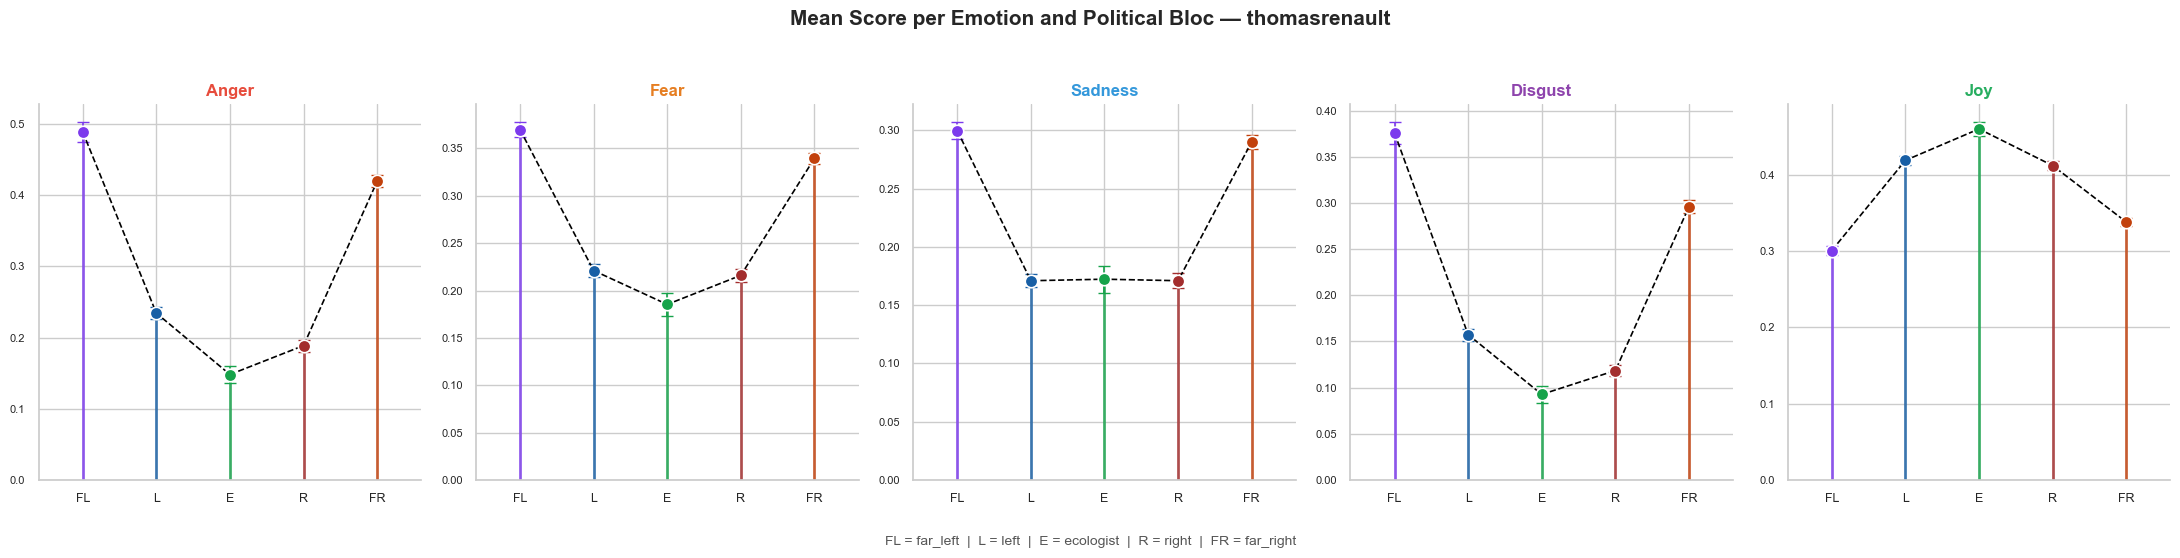

Figure saved: RQ1_per_emotion_thomasrenault_lollipop.png


In [14]:
# ── Lollipop chart — thomasrenault, 5 émotions ───────────────────────────
EMOTIONS_PER_MODEL = {
    "thomasrenault": {
        "anger":   "tr_anger",
        "fear":    "tr_fear",
        "sadness": "tr_sadness",
        "disgust": "tr_disgust",
        "joy":     "tr_joy",
    },
}
EMOTION_COLORS = {
    "anger":   "#e74c3c",
    "fear":    "#e67e22",
    "sadness": "#3498db",
    "disgust": "#8e44ad",
    "joy":     "#27ae60",
}
EMOTIONS    = ["anger", "fear", "sadness", "disgust", "joy"]
BLOC_ORDER  = ["far_left", "left", "ecologist", "right", "far_right"]
BLOC_COLORS = ["#7c3aed", "#185FA5", "#16a34a", "#A32D2D", "#c2410c"]

# ── Layout : 1 modèle × 5 émotions ───────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
fig.suptitle("Mean Score per Emotion and Political Bloc — thomasrenault",
             fontsize=15, fontweight="bold", y=1.03)

model_name   = "thomasrenault"
emotion_cols = EMOTIONS_PER_MODEL[model_name]

for col_idx, emotion in enumerate(EMOTIONS):
    ax  = axes[col_idx]
    col = emotion_cols[emotion]

    if col not in df.columns:
        ax.set_visible(False)
        continue

    stats = (
        df.groupby("bloc")[col]
        .agg(["mean", "std", "count"])
        .reindex(BLOC_ORDER)
    )
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])

    x = range(len(BLOC_ORDER))

    # ── Lollipop: stems + circles ─────────────────────────────────────
    for i, (mean_val, ci_val, color) in enumerate(
        zip(stats["mean"], stats["ci95"], BLOC_COLORS)
    ):
        # Stem
        ax.vlines(i, 0, mean_val, color=color, linewidth=2, alpha=0.8)
        # Circle head
        ax.plot(i, mean_val, "o", color=color, markersize=9,
                markeredgecolor="white", markeredgewidth=1.2, zorder=3)
        # Error bar
        ax.errorbar(i, mean_val, yerr=ci_val, fmt="none",
                    color=color, capsize=4, linewidth=1.2)

    # ── Trend line (U-shape) ──────────────────────────────────────────
    ax.plot(list(x), stats["mean"].values,
            color="black", linewidth=1.2, linestyle="--",
            marker=None, zorder=2)

    # Emotion title (no emoji)
    ax.set_title(emotion.capitalize(), fontweight="bold",
                 color=EMOTION_COLORS[emotion], fontsize=12)

    ax.set_xticks(list(x))
    ax.set_xticklabels(["FL", "L", "E", "R", "FR"], fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(-0.6, len(BLOC_ORDER) - 0.4)
    ax.set_ylim(bottom=0)
    ax.spines[["top", "right"]].set_visible(False)

# Abbreviation legend
fig.text(0.5, -0.04,
         "FL = far_left  |  L = left  |  E = ecologist  |  R = right  |  FR = far_right",
         ha="center", fontsize=10, color="#555")

plt.tight_layout()
plt.savefig("RQ1_per_emotion_thomasrenault_lollipop.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: RQ1_per_emotion_thomasrenault_lollipop.png")

## Emotional Tone by Political Bloc in Pictures

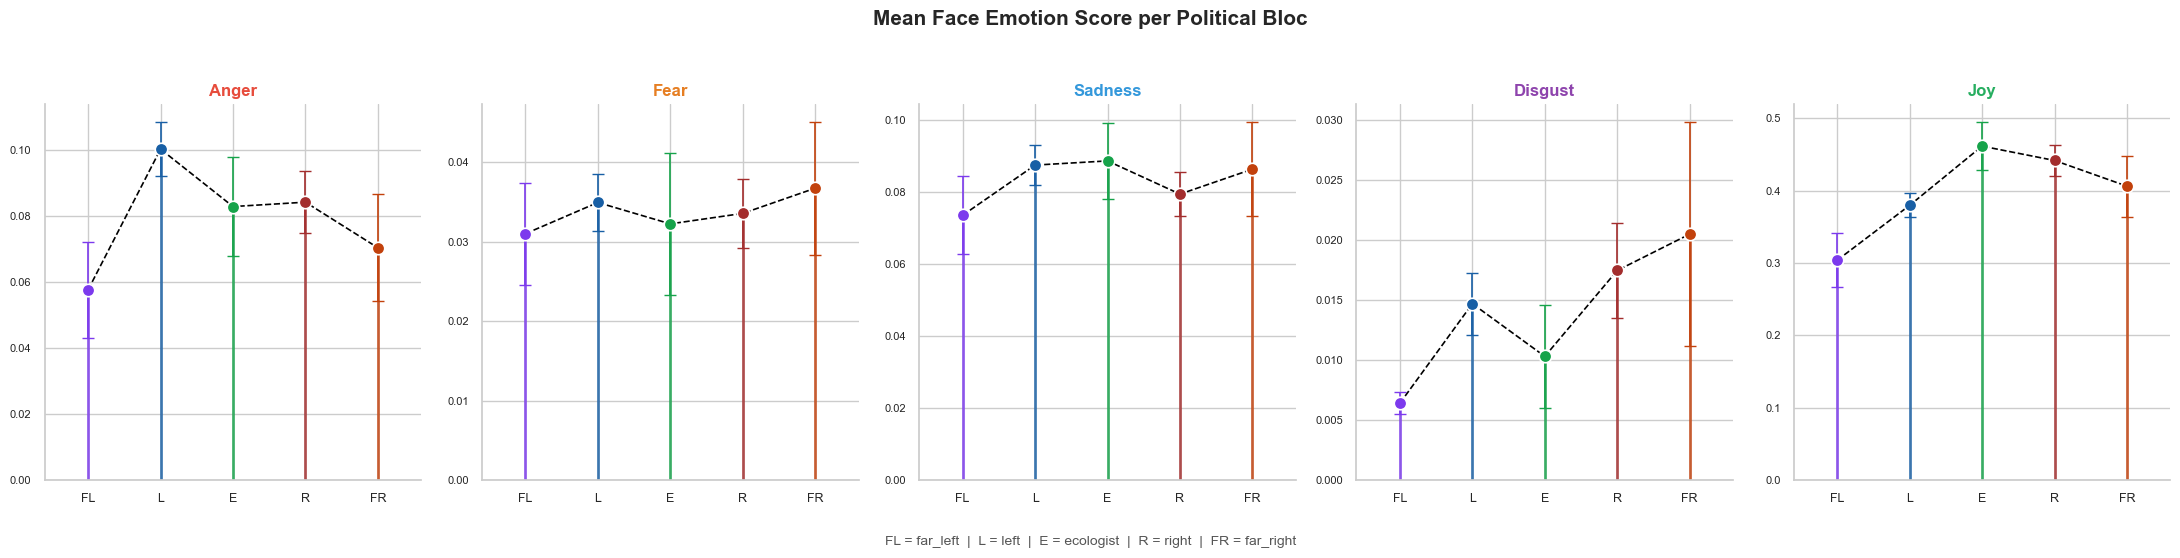

Figure saved.


In [15]:
EMOTIONS_FACE = {
    "anger":   "face_angry",
    "fear":    "face_fear",
    "sadness": "face_sad",
    "disgust": "face_disgust",
    "joy":     "face_happy",
}

EMOTION_COLORS = {
    "anger":   "#e74c3c",
    "fear":    "#e67e22",
    "sadness": "#3498db",
    "disgust": "#8e44ad",
    "joy":     "#27ae60",
}

EMOTIONS    = ["anger", "fear", "sadness", "disgust", "joy"]
BLOC_ORDER  = ["far_left", "left", "ecologist", "right", "far_right"]
BLOC_COLORS = ["#7c3aed", "#185FA5", "#16a34a", "#A32D2D", "#c2410c"]

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
fig.suptitle("Mean Face Emotion Score per Political Bloc",
             fontsize=15, fontweight="bold", y=1.03)

for col_idx, emotion in enumerate(EMOTIONS):
    ax  = axes[col_idx]
    col = EMOTIONS_FACE[emotion]

    if col not in df.columns:
        ax.set_visible(False)
        continue

    sub = df[df["face_dominant_emotion"].notna()]  # uniquement les lignes avec visage détecté

    stats = (
        sub.groupby("bloc")[col]
        .agg(["mean", "std", "count"])
        .reindex(BLOC_ORDER)
    )
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])

    x = range(len(BLOC_ORDER))

    for i, (mean_val, ci_val, color) in enumerate(
        zip(stats["mean"], stats["ci95"], BLOC_COLORS)
    ):
        ax.vlines(i, 0, mean_val, color=color, linewidth=2, alpha=0.8)
        ax.plot(i, mean_val, "o", color=color, markersize=9,
                markeredgecolor="white", markeredgewidth=1.2, zorder=3)
        ax.errorbar(i, mean_val, yerr=ci_val, fmt="none",
                    color=color, capsize=4, linewidth=1.2)

    ax.plot(list(x), stats["mean"].values,
            color="black", linewidth=1.2, linestyle="--", zorder=2)

    ax.set_title(emotion.capitalize(), fontweight="bold",
                 color=EMOTION_COLORS[emotion], fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(["FL", "L", "E", "R", "FR"], fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(-0.6, len(BLOC_ORDER) - 0.4)
    ax.set_ylim(bottom=0)
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.04,
         "FL = far_left  |  L = left  |  E = ecologist  |  R = right  |  FR = far_right",
         ha="center", fontsize=10, color="#555")

plt.tight_layout()
plt.savefig("/Users/salmaelaazdoudi/Desktop/nlp/RQ1_face_emotions_lollipop.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")